# Artefato A05 - CNN Simples (Processo Completo)

Este notebook foi montado como versao processual da entrega final. A ideia aqui nao e apenas apresentar a sintese dos resultados, mas mostrar o caminho completo:

1. exploracao final por sensor;
2. comparacao consolidada entre sensores;
3. preparacao dos dados para a CNN;
4. arquitetura efetivamente treinada;
5. historico de treino e validacao;
6. avaliacao final e comparacao com o baseline MLP.

O notebook usa:
- os notebooks em `notebooks/final` como fonte de estrutura, analise e logica;
- os artefatos em `outputs/final` como base executavel e reprodutivel nesta entrega.

## 1) Setup

O foco desta versao e manter o processo legivel dentro de um unico arquivo. Por isso, o notebook foi desenhado para rodar apenas com `outputs/final`, sem depender dos datasets parquet originais nem de TensorFlow.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mplconfig").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except Exception:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists() and (cwd / "notebooks").exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / "src").exists() and (parent / "notebooks").exists():
            return parent
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final"
CNN_DIR = OUTPUT_DIR / "a05_cnn_multissatelite"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks" / "final"

SENSOR_ORDER = ["sentinel2", "landsat89", "modis"]
SENSOR_NAMES = {
    "sentinel2": "Sentinel-2",
    "landsat89": "Landsat 8/9",
    "modis": "MODIS",
}

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as fp:
        return json.load(fp)


def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def read_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def load_sensor_bundle(sensor_key: str) -> dict:
    sensor_dir = CNN_DIR / sensor_key
    return {
        "sensor_key": sensor_key,
        "sensor_name": SENSOR_NAMES[sensor_key],
        "overview": read_json(OUTPUT_DIR / f"{sensor_key}_overview.json"),
        "band_summary": read_csv(OUTPUT_DIR / f"{sensor_key}_band_summary.csv"),
        "index_summary": read_csv(OUTPUT_DIR / f"{sensor_key}_index_summary.csv"),
        "image_counts": read_csv(OUTPUT_DIR / f"{sensor_key}_image_counts.csv"),
        "hypotheses": read_lines(OUTPUT_DIR / f"{sensor_key}_hypotheses.txt"),
        "data_prep": read_json(sensor_dir / "data_prep_summary.json"),
        "architecture": read_json(sensor_dir / "architecture_summary.json"),
        "split": read_json(sensor_dir / "split_summary.json"),
        "history": read_csv(sensor_dir / "history.csv"),
        "metrics": read_json(sensor_dir / "metrics_test.json"),
        "confusion": read_csv(sensor_dir / "confusion_matrix.csv"),
    }


artifacts = {sensor_key: load_sensor_bundle(sensor_key) for sensor_key in SENSOR_ORDER}
comparison_df = read_csv(CNN_DIR / "cnn_multissatelite_comparison.csv")
analysis_lines = read_lines(CNN_DIR / "cnn_multissatelite_analysis.txt")
compiled_overview_df = read_csv(OUTPUT_DIR / "compilado_overview.csv")
compiled_hypotheses = read_lines(OUTPUT_DIR / "compilado_hipoteses.txt")

setup_rows = []
for path in [
    NOTEBOOKS_DIR / "exploracao_sentinel2_long.ipynb",
    NOTEBOOKS_DIR / "exploracao_landsat89_long.ipynb",
    NOTEBOOKS_DIR / "exploracao_modis_long.ipynb",
    NOTEBOOKS_DIR / "exploracao_compilada_satelites_long.ipynb",
    OUTPUT_DIR / "compilado_overview.csv",
    OUTPUT_DIR / "compilado_hipoteses.txt",
    CNN_DIR / "cnn_multissatelite_comparison.csv",
]:
    setup_rows.append(
        {
            "arquivo": str(path.relative_to(PROJECT_ROOT)),
            "existe": path.exists(),
        }
    )

display(pd.DataFrame(setup_rows))
print(f"Projeto: {PROJECT_ROOT}")
print(f"Outputs finais: {OUTPUT_DIR}")

Projeto: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01
Outputs finais: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/final


,arquivo,existe
0,notebooks/final/exploracao_sentinel2_long.ipynb,True
1,notebooks/final/exploracao_landsat89_long.ipynb,True
2,notebooks/final/exploracao_modis_long.ipynb,True
3,notebooks/final/exploracao_compilada_satelites...,True
4,outputs/final/compilado_overview.csv,True
5,outputs/final/compilado_hipoteses.txt,True
6,outputs/final/a05_cnn_multissatelite/cnn_multi...,True


## 2) Fontes do processo

O notebook foi dividido em dois blocos de origem:
- **exploracao final por sensor**: baseada em `exploracao_sentinel2_long.ipynb`, `exploracao_landsat89_long.ipynb` e `exploracao_modis_long.ipynb`;
- **modelagem final da CNN**: baseada nos artefatos prontos em `outputs/final/a05_cnn_multissatelite`.

O objetivo aqui e preservar o encadeamento do raciocinio, mesmo quando a etapa de treino final nao possui um notebook-fonte equivalente em `notebooks/final`.

In [2]:
source_df = pd.DataFrame(
    [
        {
            "etapa": "Exploracao Sentinel-2",
            "fonte": "notebooks/final/exploracao_sentinel2_long.ipynb",
            "artefatos_reusados": "sentinel2_overview.json; sentinel2_band_summary.csv; sentinel2_index_summary.csv; sentinel2_image_counts.csv; sentinel2_hypotheses.txt",
        },
        {
            "etapa": "Exploracao Landsat 8/9",
            "fonte": "notebooks/final/exploracao_landsat89_long.ipynb",
            "artefatos_reusados": "landsat89_overview.json; landsat89_band_summary.csv; landsat89_index_summary.csv; landsat89_image_counts.csv; landsat89_hypotheses.txt",
        },
        {
            "etapa": "Exploracao MODIS",
            "fonte": "notebooks/final/exploracao_modis_long.ipynb",
            "artefatos_reusados": "modis_overview.json; modis_band_summary.csv; modis_index_summary.csv; modis_image_counts.csv; modis_hypotheses.txt",
        },
        {
            "etapa": "Compilacao entre sensores",
            "fonte": "notebooks/final/exploracao_compilada_satelites_long.ipynb",
            "artefatos_reusados": "compilado_overview.csv; compilado_hipoteses.txt",
        },
        {
            "etapa": "Preparacao, arquitetura, treino e avaliacao da CNN",
            "fonte": "outputs/final/a05_cnn_multissatelite/",
            "artefatos_reusados": "data_prep_summary.json; architecture_summary.json; split_summary.json; history.csv; metrics_test.json; confusion_matrix.csv; cnn_multissatelite_comparison.csv",
        },
    ]
)
display(source_df)

artifact_status_df = pd.DataFrame(
    [
        {
            "sensor": artifacts[sensor_key]["sensor_name"],
            "overview": artifacts[sensor_key]["overview"] is not None,
            "band_summary_rows": len(artifacts[sensor_key]["band_summary"]),
            "index_summary_rows": len(artifacts[sensor_key]["index_summary"]),
            "image_counts_rows": len(artifacts[sensor_key]["image_counts"]),
            "hypotheses": len(artifacts[sensor_key]["hypotheses"]),
            "history_epochs": len(artifacts[sensor_key]["history"]),
        }
        for sensor_key in SENSOR_ORDER
    ]
)
display(artifact_status_df)

,etapa,fonte,artefatos_reusados
0,Exploracao Sentinel-2,notebooks/final/exploracao_sentinel2_long.ipynb,sentinel2_overview.json; sentinel2_band_summar...
1,Exploracao Landsat 8/9,notebooks/final/exploracao_landsat89_long.ipynb,landsat89_overview.json; landsat89_band_summar...
2,Exploracao MODIS,notebooks/final/exploracao_modis_long.ipynb,modis_overview.json; modis_band_summary.csv; m...
3,Compilacao entre sensores,notebooks/final/exploracao_compilada_satelites...,compilado_overview.csv; compilado_hipoteses.txt
4,"Preparacao, arquitetura, treino e avaliacao da...",outputs/final/a05_cnn_multissatelite/,data_prep_summary.json; architecture_summary.j...


,sensor,overview,band_summary_rows,index_summary_rows,image_counts_rows,hypotheses,history_epochs
0,Sentinel-2,True,12,4,1356,4,11
1,Landsat 8/9,True,7,4,1532,4,28
2,MODIS,True,7,4,1575,4,13


## 3) Exploracao do Sentinel-2

Esta secao resume, em formato enxuto mas processual, o fluxo do notebook `exploracao_sentinel2_long.ipynb`: visao geral do dataset longo, estatisticas de banda, variabilidade por imagem, indices espectrais e hipoteses.

In [3]:
sensor = artifacts["sentinel2"]
overview = pd.Series(sensor["overview"], name="valor").to_frame()
display(overview)

sentinel_overview_df = pd.DataFrame(
    {
        "band": sensor["band_summary"]["band"],
        "mean": sensor["band_summary"]["mean"],
        "std": sensor["band_summary"]["std"],
        "zero_pct": sensor["band_summary"]["zero_pct"],
    }
)
display(sentinel_overview_df.head(12))

display(sensor["image_counts"]["n_pixels"].describe().to_frame("n_pixels"))

,valor
sensor,Sentinel-2
n_rows_total,93963765
n_rows_analysis,93963765
n_columns,13
n_bands,12
n_images,1356


,band,mean,std,zero_pct
0,B1,340.474304,143.075348,2.841745
1,B2,437.974884,207.373230,2.824359
2,B3,694.415100,281.843048,2.807055
3,B4,876.179382,484.311462,2.807206
4,B5,1304.651001,487.405762,2.806985
5,B6,1946.184082,530.648621,2.807125
6,B7,2207.607910,620.833374,2.807062
7,B8,2322.274414,651.372925,2.807021
8,B9,2488.664795,665.710205,2.807080
9,B10,2492.107178,629.315430,2.823040


,n_pixels
count,1356.000000
mean,69294.811947
std,1059.663611
min,66049.000000
25%,69133.000000
50%,69402.000000
75%,69918.000000
max,71208.000000


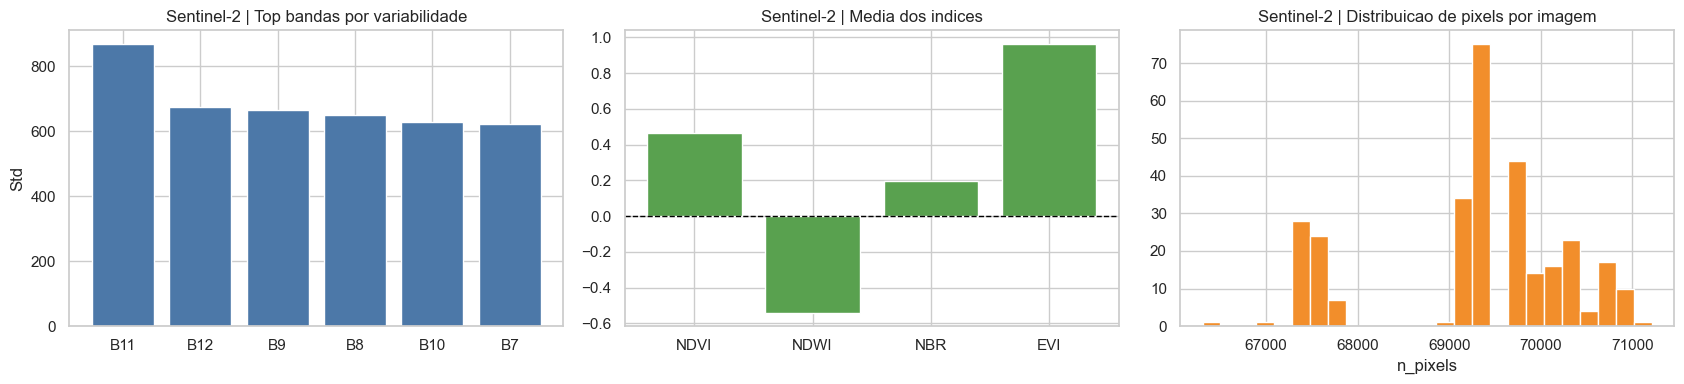

In [4]:
sensor = artifacts["sentinel2"]
band_df = sensor["band_summary"].copy().sort_values("std", ascending=False)
idx_df = sensor["index_summary"].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].bar(band_df["band"].head(6), band_df["std"].head(6), color="#4C78A8")
axes[0].set_title("Sentinel-2 | Top bandas por variabilidade")
axes[0].set_ylabel("Std")

axes[1].bar(idx_df["index_name"], idx_df["mean"], color="#59A14F")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Sentinel-2 | Media dos indices")

sampled_counts = sensor["image_counts"]["n_pixels"].sample(
    min(300, len(sensor["image_counts"])), random_state=42
)
axes[2].hist(sampled_counts, bins=25, color="#F28E2B", edgecolor="white")
axes[2].set_title("Sentinel-2 | Distribuicao de pixels por imagem")
axes[2].set_xlabel("n_pixels")

plt.tight_layout()
plt.show()

In [5]:
sensor = artifacts["sentinel2"]
hypotheses_md = ["### Hipoteses finais do Sentinel-2"]
hypotheses_md.extend(f"- {line}" for line in sensor["hypotheses"])
display(Markdown("\n".join(hypotheses_md)))

### Hipoteses finais do Sentinel-2
- Bandas com maior variabilidade (B11, B12, B9) podem carregar maior poder discriminativo para classificacao.
- Existe redundancia espectral relevante em B7~B9 (r=0.99); B6~B7 (r=0.98); B6~B9 (r=0.98). Vale testar PCA/selecionador de features.
- Ha variacao entre imagens na media espectral. Hipotese: padroes temporais/atmosfericos influenciam os sinais e exigem normalizacao por cena.
- NDVI medio=0.467 (std=0.201). Testar mascaramento de vegetacao para reduzir ruido no alvo mineral.

## 4) Exploracao do Landsat 8/9

Esta secao resume o fluxo do notebook `exploracao_landsat89_long.ipynb`, mantendo a leitura sobre volume, bandas, imagens, indices e hipoteses do sensor.

In [6]:
sensor = artifacts["landsat89"]
overview = pd.Series(sensor["overview"], name="valor").to_frame()
display(overview)

landsat_overview_df = pd.DataFrame(
    {
        "band": sensor["band_summary"]["band"],
        "mean": sensor["band_summary"]["mean"],
        "std": sensor["band_summary"]["std"],
        "zero_pct": sensor["band_summary"]["zero_pct"],
    }
)
display(landsat_overview_df.head(10))

display(sensor["image_counts"]["n_pixels"].describe().to_frame("n_pixels"))

,valor
sensor,Landsat 8/9
n_rows_total,105977560
n_rows_analysis,105977560
n_columns,8
n_bands,7
n_images,1532


,band,mean,std,zero_pct
0,B1,0.030695,0.016082,3.623057
1,B2,0.057270,0.024689,3.623022
2,B3,0.063533,0.038222,3.623022
3,B4,0.244367,0.073156,3.623022
4,B5,0.213026,0.089183,3.623022
5,B6,0.121174,0.065798,3.623022
6,B7,297.271179,33.219189,0.000000


,n_pixels
count,1532.000000
mean,69175.953003
std,1137.926879
min,66048.000000
25%,69133.000000
50%,69390.000000
75%,69904.000000
max,71208.000000


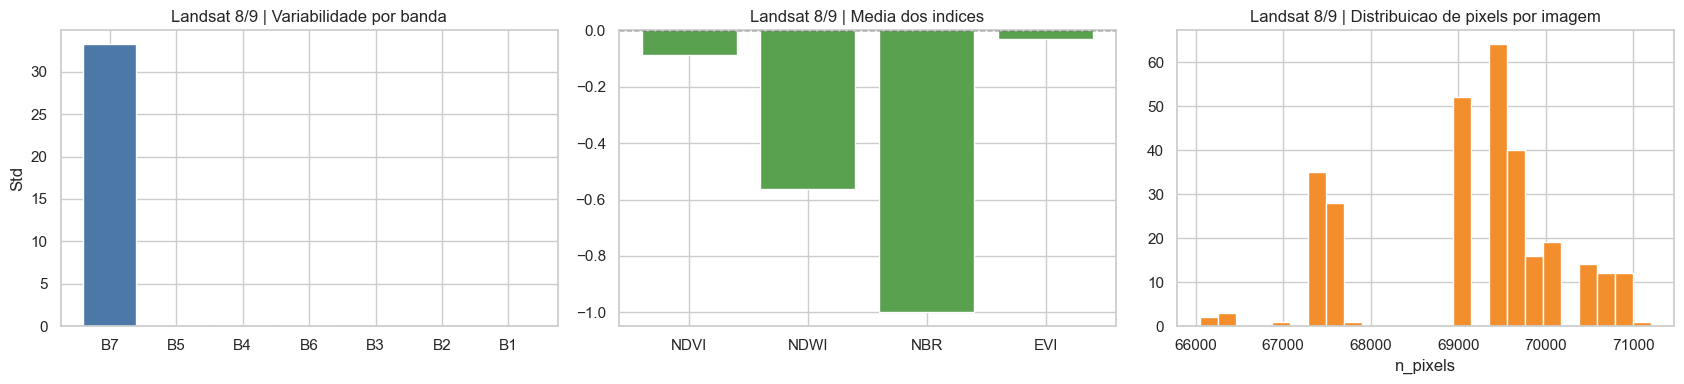

In [7]:
sensor = artifacts["landsat89"]
band_df = sensor["band_summary"].copy().sort_values("std", ascending=False)
idx_df = sensor["index_summary"].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].bar(band_df["band"], band_df["std"], color="#4C78A8")
axes[0].set_title("Landsat 8/9 | Variabilidade por banda")
axes[0].set_ylabel("Std")

axes[1].bar(idx_df["index_name"], idx_df["mean"], color="#59A14F")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Landsat 8/9 | Media dos indices")

sampled_counts = sensor["image_counts"]["n_pixels"].sample(
    min(300, len(sensor["image_counts"])), random_state=42
)
axes[2].hist(sampled_counts, bins=25, color="#F28E2B", edgecolor="white")
axes[2].set_title("Landsat 8/9 | Distribuicao de pixels por imagem")
axes[2].set_xlabel("n_pixels")

plt.tight_layout()
plt.show()

In [8]:
sensor = artifacts["landsat89"]
hypotheses_md = ["### Hipoteses finais do Landsat 8/9"]
hypotheses_md.extend(f"- {line}" for line in sensor["hypotheses"])
display(Markdown("\n".join(hypotheses_md)))

### Hipoteses finais do Landsat 8/9
- Bandas com maior variabilidade (B7, B5, B4) podem carregar maior poder discriminativo para classificacao.
- Existe redundancia espectral relevante em B5~B6 (r=0.97); B1~B2 (r=0.96); B1~B3 (r=0.96). Vale testar PCA/selecionador de features.
- Ha variacao entre imagens na media espectral. Hipotese: padroes temporais/atmosfericos influenciam os sinais e exigem normalizacao por cena.
- NDVI medio=-0.086 (std=0.827). Testar mascaramento de vegetacao para reduzir ruido no alvo mineral.

## 5) Exploracao do MODIS

Esta secao resume o fluxo do notebook `exploracao_modis_long.ipynb`, mantendo o diagnostico sobre bandas, indices, volume e hipoteses do sensor.

In [9]:
sensor = artifacts["modis"]
overview = pd.Series(sensor["overview"], name="valor").to_frame()
display(overview)

modis_overview_df = pd.DataFrame(
    {
        "band": sensor["band_summary"]["band"],
        "mean": sensor["band_summary"]["mean"],
        "std": sensor["band_summary"]["std"],
        "zero_pct": sensor["band_summary"]["zero_pct"],
    }
)
display(modis_overview_df.head(10))

display(sensor["image_counts"]["n_pixels"].describe().to_frame("n_pixels"))

,valor
sensor,MODIS
n_rows_total,109016100
n_rows_analysis,109016100
n_columns,8
n_bands,7
n_images,1575


,band,mean,std,zero_pct
0,B1,720.490051,5712.387207,0.000638
1,B2,2747.701172,6182.770996,0.002192
2,B3,395.458435,5674.198730,0.004708
3,B4,758.346863,5712.354980,0.000929
4,B5,2908.681885,5928.176758,0.000547
5,B6,1838.137939,5707.738281,0.000000
6,B7,569.284607,5452.438477,0.000321


,n_pixels
count,1575.000000
mean,69216.571429
std,1170.885194
min,65792.000000
25%,69133.000000
50%,69390.000000
75%,69918.000000
max,71208.000000


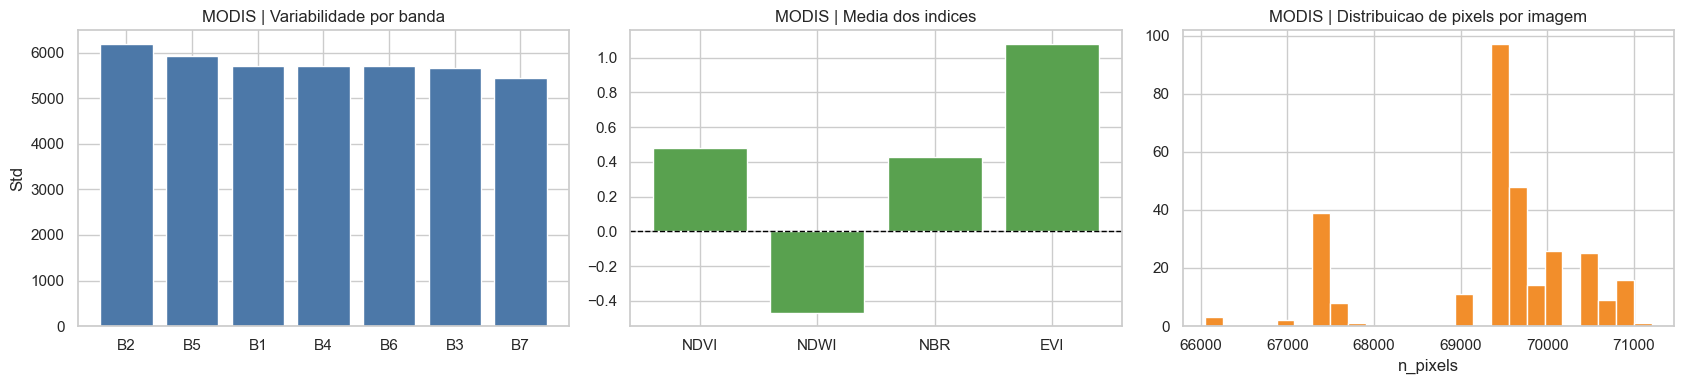

In [10]:
sensor = artifacts["modis"]
band_df = sensor["band_summary"].copy().sort_values("std", ascending=False)
idx_df = sensor["index_summary"].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].bar(band_df["band"], band_df["std"], color="#4C78A8")
axes[0].set_title("MODIS | Variabilidade por banda")
axes[0].set_ylabel("Std")

axes[1].bar(idx_df["index_name"], idx_df["mean"], color="#59A14F")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("MODIS | Media dos indices")

sampled_counts = sensor["image_counts"]["n_pixels"].sample(
    min(300, len(sensor["image_counts"])), random_state=42
)
axes[2].hist(sampled_counts, bins=25, color="#F28E2B", edgecolor="white")
axes[2].set_title("MODIS | Distribuicao de pixels por imagem")
axes[2].set_xlabel("n_pixels")

plt.tight_layout()
plt.show()

In [11]:
sensor = artifacts["modis"]
hypotheses_md = ["### Hipoteses finais do MODIS"]
hypotheses_md.extend(f"- {line}" for line in sensor["hypotheses"])
display(Markdown("\n".join(hypotheses_md)))

### Hipoteses finais do MODIS
- Bandas com maior variabilidade (B2, B5, B1) podem carregar maior poder discriminativo para classificacao.
- Existe redundancia espectral relevante em B1~B4 (r=1.00); B3~B4 (r=1.00); B1~B3 (r=1.00). Vale testar PCA/selecionador de features.
- Ha variacao entre imagens na media espectral. Hipotese: padroes temporais/atmosfericos influenciam os sinais e exigem normalizacao por cena.
- NDVI medio=0.482 (std=0.305). Testar mascaramento de vegetacao para reduzir ruido no alvo mineral.

## 6) Exploracao compilada entre sensores

Aqui entra o papel do notebook `exploracao_compilada_satelites_long.ipynb`: comparar os sensores e transformar a EDA individual em uma leitura integrada para a modelagem.

,sensor,n_rows_total,n_rows_analysis,n_bands,n_images
0,Landsat 8/9,105977560,105977560,7,1532
1,MODIS,109016100,109016100,7,1575
2,Sentinel-2,93963765,93963765,12,1356


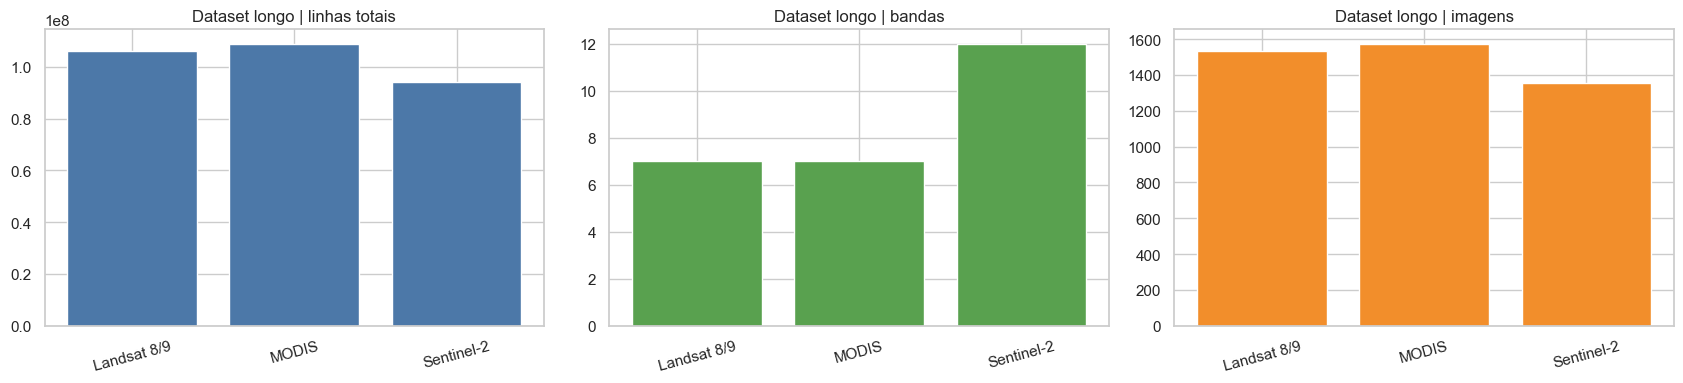

,sensor,index_name,mean,std,min,max
0,Sentinel-2,NDVI,0.466896,0.201014,-0.642276,0.992431
1,Sentinel-2,NDWI,-0.540513,0.123087,-0.939994,0.865854
2,Sentinel-2,NBR,0.197866,0.204640,-0.600000,0.869876
3,Sentinel-2,EVI,0.964388,0.921003,-325.000000,67.534248
4,Landsat 8/9,NDVI,-0.086193,0.827174,-213.400360,187.000046
5,Landsat 8/9,NDWI,-0.561558,0.118666,-13.820514,1.083275
6,Landsat 8/9,NBR,-0.998587,0.000624,-1.000012,-0.992373
7,Landsat 8/9,EVI,-0.028751,0.083274,-0.311862,0.583366
8,MODIS,NDVI,0.481508,0.304586,-55.666668,36.200001
9,MODIS,NDWI,-0.467639,0.253070,-3.255319,6.263158


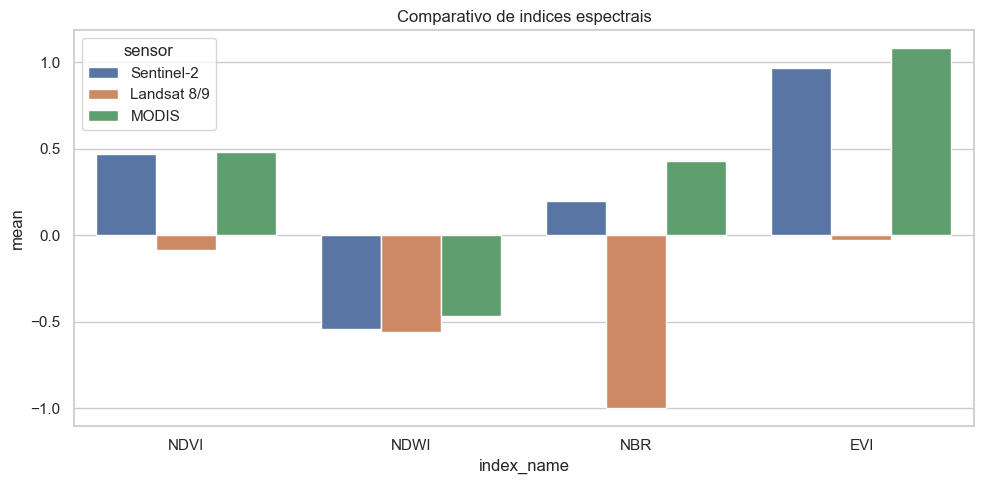

In [12]:
overview_df = compiled_overview_df.copy()
overview_df["sensor"] = overview_df["sensor_key"].map(SENSOR_NAMES)
overview_df = overview_df[
    ["sensor", "n_rows_total", "n_rows_analysis", "n_bands", "n_images"]
].sort_values("sensor", ignore_index=True)
display(overview_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].bar(overview_df["sensor"], overview_df["n_rows_total"], color="#4C78A8")
axes[0].set_title("Dataset longo | linhas totais")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(overview_df["sensor"], overview_df["n_bands"], color="#59A14F")
axes[1].set_title("Dataset longo | bandas")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(overview_df["sensor"], overview_df["n_images"], color="#F28E2B")
axes[2].set_title("Dataset longo | imagens")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

all_indices = []
for sensor_key in SENSOR_ORDER:
    idx_df = artifacts[sensor_key]["index_summary"].copy()
    idx_df["sensor"] = SENSOR_NAMES[sensor_key]
    all_indices.append(idx_df)
indices_df = pd.concat(all_indices, ignore_index=True)
display(indices_df[["sensor", "index_name", "mean", "std", "min", "max"]])

plt.figure(figsize=(10, 5))
if sns is not None:
    sns.barplot(data=indices_df, x="index_name", y="mean", hue="sensor")
else:
    pivot = indices_df.pivot(index="index_name", columns="sensor", values="mean")
    pivot.plot(kind="bar")
plt.title("Comparativo de indices espectrais")
plt.tight_layout()
plt.show()

In [13]:
compiled_md = ["### Hipoteses consolidadas"]
compiled_md.extend(f"- {line}" for line in compiled_hypotheses)
display(Markdown("\n".join(compiled_md)))

### Hipoteses consolidadas
- O sensor com maior volume de pixels e modis; testar estrategias de balanceamento na etapa integrada.
- Landsat 89 apresentou maior taxa media de faltantes nas bandas; avaliar imputacao/mascara especifica por sensor.
- As medias de NDVI variam entre sensores; testar normalizacao por sensor antes de treinar modelos unificados.

## 7) Preparacao dos dados para a CNN

A partir da exploracao final, a unidade de trabalho sai do pixel em formato longo e passa para o tile rotulado por sensor. Esta secao reconstroi a etapa de preparacao a partir de `data_prep_summary.json`, `split_summary.json` e `image_counts.csv`.

In [14]:
prep_rows = []
split_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    prep = item["data_prep"]
    split = item["split"]
    prep_rows.append(
        {
            "sensor": item["sensor_name"],
            "linhas_dataset_longo": item["overview"]["n_rows_total"],
            "imagens_dataset_longo": item["overview"]["n_images"],
            "n_images_rotuladas": prep["n_images_after_label_filter"],
            "shape_tensor": " x ".join(str(v) for v in prep["tensor_shape"]),
            "height": prep["height"],
            "width": prep["width"],
            "n_bands": prep["n_bands"],
            "classe_0": prep["class_balance"].get("0", 0),
            "classe_1": prep["class_balance"].get("1", 0),
            "n_train": split["n_train"],
            "n_val": split["n_val"],
            "n_test": split["n_test"],
            "mediana_pixels_por_imagem_longo": float(item["image_counts"]["n_pixels"].median()),
        }
    )
    for split_name, key in [("train", "class_balance_train"), ("val", "class_balance_val"), ("test", "class_balance_test")]:
        split_rows.append(
            {
                "sensor": item["sensor_name"],
                "split": split_name,
                "negativo_0": split[key].get("0", 0),
                "positivo_1": split[key].get("1", 0),
            }
        )

prep_df = pd.DataFrame(prep_rows).sort_values("sensor", ignore_index=True)
split_df = pd.DataFrame(split_rows)
display(prep_df)
display(split_df)

,sensor,linhas_dataset_longo,imagens_dataset_longo,n_images_rotuladas,shape_tensor,height,width,n_bands,classe_0,classe_1,n_train,n_val,n_test,mediana_pixels_por_imagem_longo
0,Landsat 8/9,105977560,1532,255,255 x 257 x 270 x 7,257,270,7,85,170,178,38,39,69390.0
1,MODIS,109016100,1575,430,430 x 257 x 270 x 7,257,270,7,110,320,301,64,65,69390.0
2,Sentinel-2,93963765,1356,212,212 x 257 x 270 x 12,257,270,12,62,150,148,32,32,69402.0


,sensor,split,negativo_0,positivo_1
0,Sentinel-2,train,43,105
1,Sentinel-2,val,9,23
2,Sentinel-2,test,10,22
3,Landsat 8/9,train,59,119
4,Landsat 8/9,val,13,25
5,Landsat 8/9,test,13,26
6,MODIS,train,77,224
7,MODIS,val,16,48
8,MODIS,test,17,48


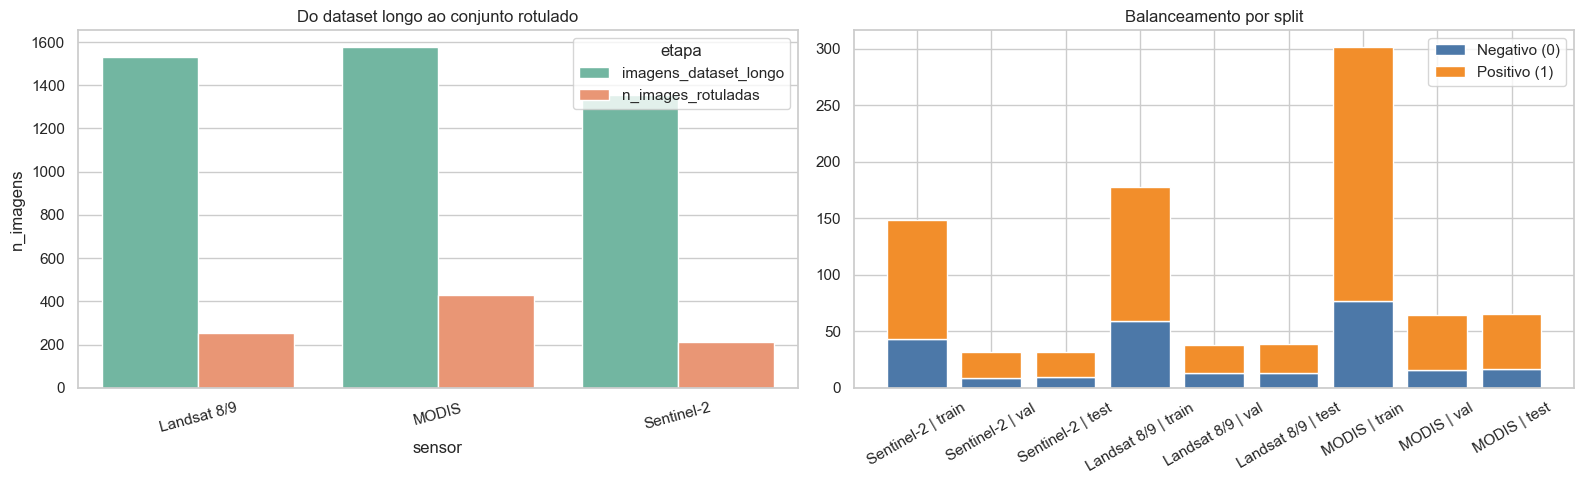

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

image_view = prep_df.melt(
    id_vars="sensor",
    value_vars=["imagens_dataset_longo", "n_images_rotuladas"],
    var_name="etapa",
    value_name="n_imagens",
)
if sns is not None:
    sns.barplot(data=image_view, x="sensor", y="n_imagens", hue="etapa", ax=axes[0], palette="Set2")
else:
    image_view.pivot(index="sensor", columns="etapa", values="n_imagens").plot(kind="bar", ax=axes[0])
axes[0].set_title("Do dataset longo ao conjunto rotulado")
axes[0].tick_params(axis="x", rotation=15)

split_plot_df = split_df.copy()
split_plot_df["sensor_split"] = split_plot_df["sensor"] + " | " + split_plot_df["split"]
axes[1].bar(split_plot_df["sensor_split"], split_plot_df["negativo_0"], label="Negativo (0)", color="#4C78A8")
axes[1].bar(
    split_plot_df["sensor_split"],
    split_plot_df["positivo_1"],
    bottom=split_plot_df["negativo_0"],
    label="Positivo (1)",
    color="#F28E2B",
)
axes[1].set_title("Balanceamento por split")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()

## 8) Arquitetura da CNN simples

Esta secao mostra a arquitetura que foi efetivamente usada nos resultados finais. A ideia-base permanece simples e consistente entre sensores: dois blocos convolucionais, `Flatten`, camada densa e saida binaria.

In [16]:
architecture_rows = []
layers_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    arch = item["architecture"]
    layers = arch["layers_info"]
    architecture_rows.append(
        {
            "sensor": item["sensor_name"],
            "input_shape": tuple(item["metrics"]["input_shape"]),
            "total_params": arch["total_params"],
            "trainable_params": arch["trainable_params"],
            "n_layers": len(layers),
            "pipeline": " -> ".join(layer["type"] for layer in layers),
        }
    )
    for idx, layer in enumerate(layers, start=1):
        layers_rows.append(
            {
                "sensor": item["sensor_name"],
                "ordem": idx,
                "layer_name": layer["name"],
                "layer_type": layer["type"],
                "params": layer["params"],
                "output_shape": tuple(layer["output_shape"]) if layer.get("output_shape") else None,
            }
        )

architecture_df = pd.DataFrame(architecture_rows).sort_values("sensor", ignore_index=True)
layers_df = pd.DataFrame(layers_rows)
display(architecture_df)
display(layers_df)

,sensor,input_shape,total_params,trainable_params,n_layers,pipeline
0,Landsat 8/9,"(257, 270, 7)",35148226,35148226,10,Conv2D -> Dropout -> MaxPooling2D -> Conv2D ->...
1,MODIS,"(257, 270, 7)",35148226,35148226,10,Conv2D -> Dropout -> MaxPooling2D -> Conv2D ->...
2,Sentinel-2,"(257, 270, 12)",35149666,35149666,10,Conv2D -> Dropout -> MaxPooling2D -> Conv2D ->...


,sensor,ordem,layer_name,layer_type,params,output_shape
0,Sentinel-2,1,conv2d_1,Conv2D,3488,"(None, 257, 270, 32)"
1,Sentinel-2,2,dropout_conv1,Dropout,0,"(None, 257, 270, 32)"
2,Sentinel-2,3,maxpooling2d_1,MaxPooling2D,0,"(None, 128, 135, 32)"
3,Sentinel-2,4,conv2d_2,Conv2D,18496,"(None, 128, 135, 64)"
4,Sentinel-2,5,dropout_conv2,Dropout,0,"(None, 128, 135, 64)"
5,Sentinel-2,6,maxpooling2d_2,MaxPooling2D,0,"(None, 64, 67, 64)"
6,Sentinel-2,7,flatten,Flatten,0,"(None, 274432)"
7,Sentinel-2,8,dense_hidden,Dense,35127424,"(None, 128)"
8,Sentinel-2,9,dropout_dense,Dropout,0,"(None, 128)"
9,Sentinel-2,10,output,Dense,258,"(None, 2)"


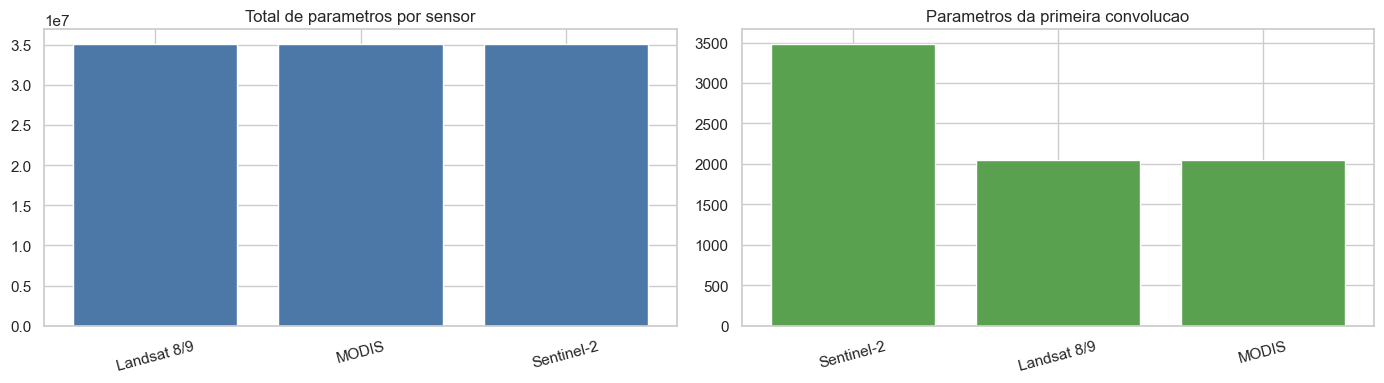

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(architecture_df["sensor"], architecture_df["total_params"], color="#4C78A8")
axes[0].set_title("Total de parametros por sensor")
axes[0].tick_params(axis="x", rotation=15)

first_conv_params = []
for sensor_key in SENSOR_ORDER:
    layers = artifacts[sensor_key]["architecture"]["layers_info"]
    first_conv_params.append(
        {
            "sensor": SENSOR_NAMES[sensor_key],
            "conv1_params": next(layer["params"] for layer in layers if layer["type"] == "Conv2D"),
        }
    )
first_conv_df = pd.DataFrame(first_conv_params)
axes[1].bar(first_conv_df["sensor"], first_conv_df["conv1_params"], color="#59A14F")
axes[1].set_title("Parametros da primeira convolucao")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 9) Treinamento e validacao

Como o treino final nao esta descrito em notebook dentro de `notebooks/final`, esta etapa foi reconstruida a partir dos historicos exportados em `history.csv`.

In [18]:
history_summary_rows = []
sampled_history_parts = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    hist = item["history"].copy()
    hist.index = np.arange(1, len(hist) + 1)
    best_epoch_acc = int(hist["val_accuracy"].idxmax())
    best_epoch_loss = int(hist["val_loss"].idxmin())
    history_summary_rows.append(
        {
            "sensor": item["sensor_name"],
            "epochs_ran": item["metrics"]["epochs_ran"],
            "best_epoch_val_acc": best_epoch_acc,
            "best_val_acc": hist["val_accuracy"].max(),
            "best_epoch_val_loss": best_epoch_loss,
            "best_val_loss": hist["val_loss"].min(),
            "final_train_acc": hist["accuracy"].iloc[-1],
            "final_val_acc": hist["val_accuracy"].iloc[-1],
            "gap_train_minus_val_acc": item["metrics"]["generalization_gap_train_minus_val_acc"],
        }
    )
    sampled = hist.loc[:, ["accuracy", "val_accuracy", "loss", "val_loss"]].copy()
    sampled = sampled.loc[(sampled.index % 3 == 1) | (sampled.index == sampled.index.max())]
    sampled["sensor"] = item["sensor_name"]
    sampled["epoch"] = sampled.index
    sampled_history_parts.append(sampled.reset_index(drop=True))

history_summary_df = pd.DataFrame(history_summary_rows).sort_values("sensor", ignore_index=True)
sampled_history_df = pd.concat(sampled_history_parts, ignore_index=True)

display(history_summary_df)
display(sampled_history_df)

,sensor,epochs_ran,best_epoch_val_acc,best_val_acc,best_epoch_val_loss,best_val_loss,final_train_acc,final_val_acc,gap_train_minus_val_acc
0,Landsat 8/9,28,13,0.842105,20,0.982496,0.938202,0.789474,0.148729
1,MODIS,13,1,0.890625,5,1.107429,0.956811,0.421875,0.534936
2,Sentinel-2,11,5,0.812500,3,1.219897,0.905405,0.812500,0.092905


,accuracy,val_accuracy,loss,val_loss,sensor,epoch
0,0.513514,0.781250,22.672613,3.655215,Sentinel-2,1
1,0.851351,0.750000,1.133746,1.750176,Sentinel-2,4
2,0.871622,0.812500,1.195043,1.535404,Sentinel-2,7
3,0.898649,0.812500,1.006320,1.510217,Sentinel-2,10
4,0.905405,0.812500,0.933564,1.369554,Sentinel-2,11
5,0.539326,0.736842,21.090530,1.700159,Landsat 8/9,1
6,0.691011,0.684211,1.331362,1.298147,Landsat 8/9,4
7,0.831461,0.763158,1.124514,1.205401,Landsat 8/9,7
8,0.876405,0.736842,1.000229,1.234715,Landsat 8/9,10
9,0.910112,0.842105,0.909034,1.044119,Landsat 8/9,13


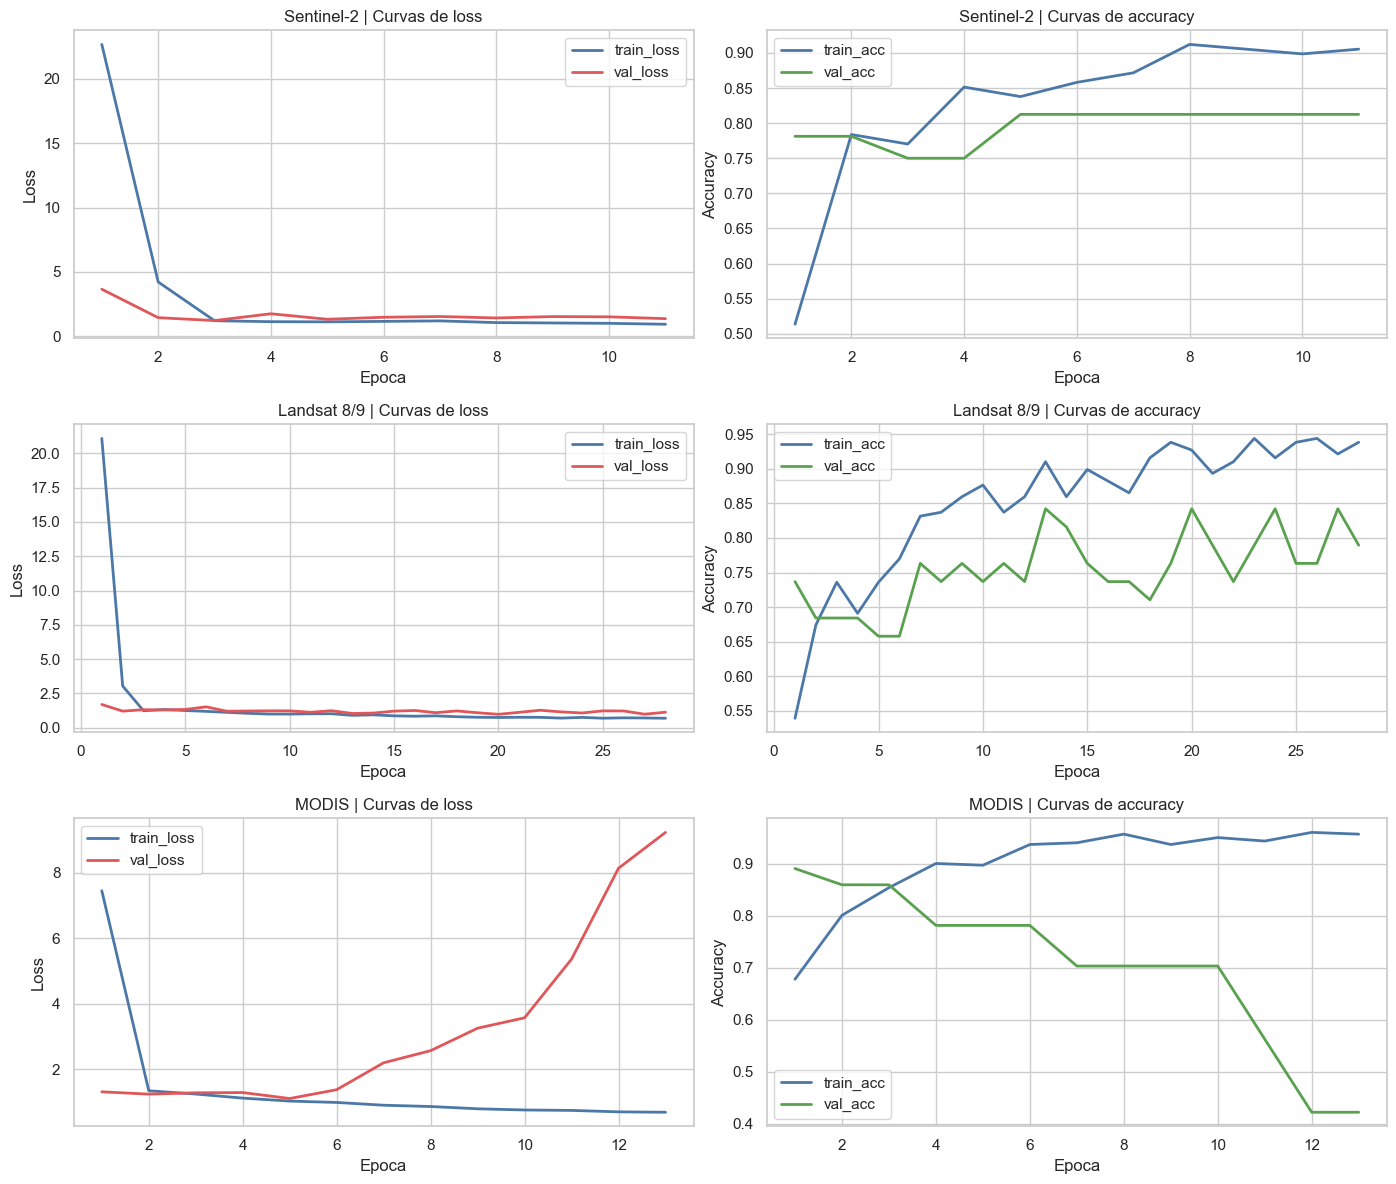

In [19]:
fig, axes = plt.subplots(len(SENSOR_ORDER), 2, figsize=(14, 4 * len(SENSOR_ORDER)))
for row_idx, sensor_key in enumerate(SENSOR_ORDER):
    item = artifacts[sensor_key]
    hist = item["history"].copy()
    hist.index = np.arange(1, len(hist) + 1)

    ax_loss = axes[row_idx, 0]
    ax_acc = axes[row_idx, 1]

    ax_loss.plot(hist.index, hist["loss"], linewidth=2, color="#4C78A8", label="train_loss")
    ax_loss.plot(hist.index, hist["val_loss"], linewidth=2, color="#E15759", label="val_loss")
    ax_loss.set_title(f"{item['sensor_name']} | Curvas de loss")
    ax_loss.set_xlabel("Epoca")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    ax_acc.plot(hist.index, hist["accuracy"], linewidth=2, color="#4C78A8", label="train_acc")
    ax_acc.plot(hist.index, hist["val_accuracy"], linewidth=2, color="#59A14F", label="val_acc")
    ax_acc.set_title(f"{item['sensor_name']} | Curvas de accuracy")
    ax_acc.set_xlabel("Epoca")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

plt.tight_layout()
plt.show()

## 10) Avaliacao quantitativa

A avaliacao final combina as metricas de `metrics_test.json`, as matrizes de confusao e a tabela comparativa consolidada entre sensores.

In [20]:
metrics_rows = []
confusion_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    metrics = item["metrics"]["classification_metrics_test"]
    metrics_rows.append(
        {
            "sensor": item["sensor_name"],
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "roc_auc": metrics["roc_auc"],
            "pr_auc": metrics["pr_auc"],
            "test_loss": item["metrics"]["keras_test_metrics"]["loss"],
            "train_time_s": item["metrics"]["train_time_s"],
        }
    )

    cm = item["confusion"].to_numpy(dtype=int)
    tn, fp = cm[0]
    fn, tp = cm[1]
    confusion_rows.append(
        {
            "sensor": item["sensor_name"],
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values("sensor", ignore_index=True)
confusion_df = pd.DataFrame(confusion_rows).sort_values("sensor", ignore_index=True)
display(metrics_df)
display(confusion_df)

,sensor,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc,test_loss,train_time_s
0,Landsat 8/9,0.846154,0.812500,1.000000,0.896552,0.769231,0.852071,0.849442,1.028646,399.078680
1,MODIS,0.769231,0.851064,0.833333,0.842105,0.710784,0.716912,0.859810,2.188438,188.968475
2,Sentinel-2,0.843750,0.840000,0.954545,0.893617,0.777273,0.877273,0.941475,1.254655,92.725890


,sensor,tn,fp,fn,tp,specificity,sensitivity
0,Landsat 8/9,7,6,0,26,0.538462,1.000000
1,MODIS,10,7,8,40,0.588235,0.833333
2,Sentinel-2,6,4,1,21,0.600000,0.954545


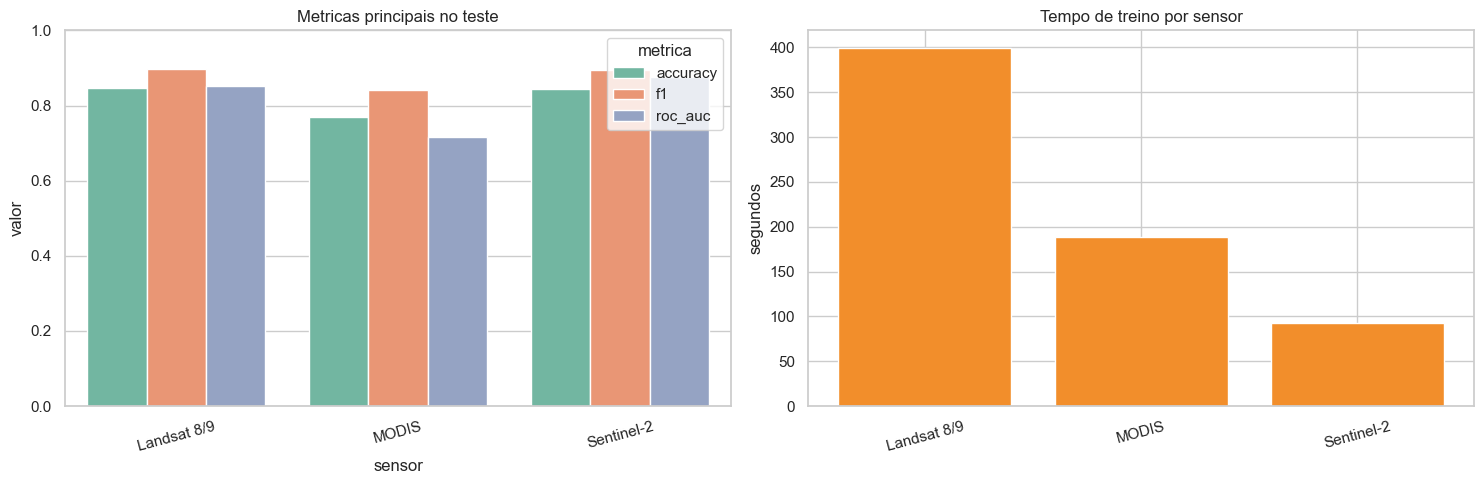

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metric_plot_df = metrics_df.melt(
    id_vars="sensor",
    value_vars=["accuracy", "f1", "roc_auc"],
    var_name="metrica",
    value_name="valor",
)
if sns is not None:
    sns.barplot(data=metric_plot_df, x="sensor", y="valor", hue="metrica", ax=axes[0], palette="Set2")
else:
    metric_plot_df.pivot(index="sensor", columns="metrica", values="valor").plot(kind="bar", ax=axes[0])
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Metricas principais no teste")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(metrics_df["sensor"], metrics_df["train_time_s"], color="#F28E2B")
axes[1].set_title("Tempo de treino por sensor")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_ylabel("segundos")
plt.tight_layout()
plt.show()

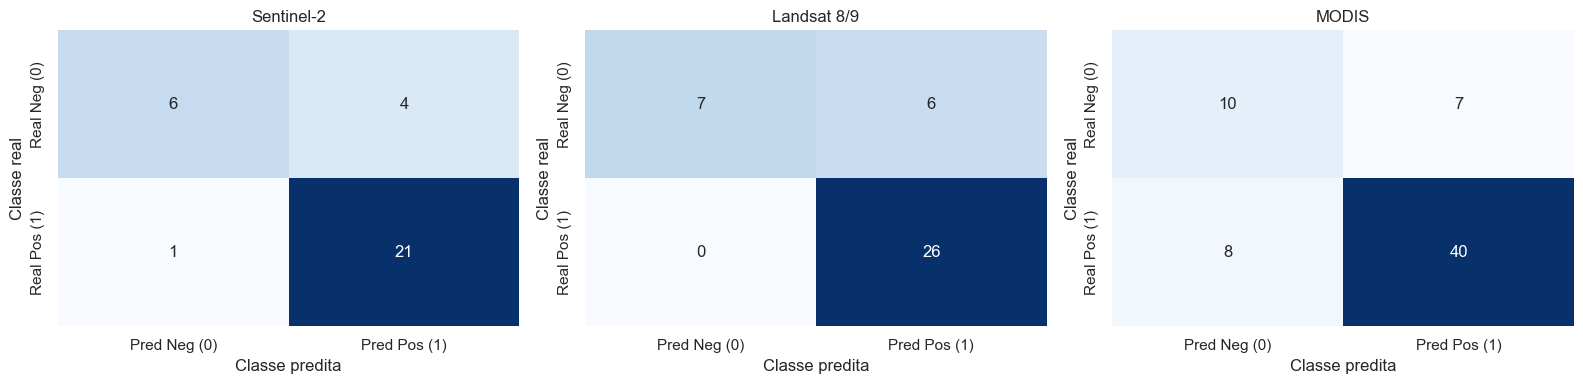

In [22]:
fig, axes = plt.subplots(1, len(SENSOR_ORDER), figsize=(16, 4))
for idx, sensor_key in enumerate(SENSOR_ORDER):
    item = artifacts[sensor_key]
    cm = item["confusion"].to_numpy(dtype=int)
    ax = axes[idx]
    if sns is not None:
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Pred Neg (0)", "Pred Pos (1)"],
            yticklabels=["Real Neg (0)", "Real Pos (1)"],
            ax=ax,
        )
    else:
        ax.imshow(cm, cmap="Blues")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
        ax.set_xticks([0, 1], ["Pred Neg (0)", "Pred Pos (1)"])
        ax.set_yticks([0, 1], ["Real Neg (0)", "Real Pos (1)"])
    ax.set_title(item["sensor_name"])
    ax.set_xlabel("Classe predita")
    ax.set_ylabel("Classe real")
plt.tight_layout()
plt.show()

## 11) Comparacao com o baseline MLP

Esta etapa fecha a avaliacao quantitativa usando a comparacao consolidada salva em `cnn_multissatelite_comparison.csv`.

,sensor,cnn_accuracy,cnn_f1,cnn_balanced_accuracy,generalization_gap,epochs_ran,mlp_accuracy_sprint2,delta_acc_cnn_minus_mlp
0,Landsat 8/9,0.846154,0.896552,0.769231,0.148729,28,0.813559,0.032595
1,MODIS,0.769231,0.842105,0.710784,0.534936,13,0.813559,-0.044329
2,Sentinel-2,0.843750,0.893617,0.777273,0.092905,11,0.813559,0.030191


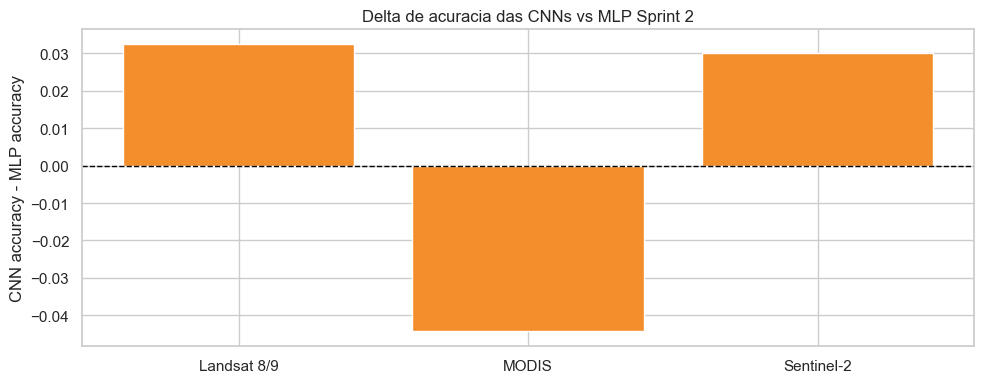

In [23]:
mlp_compare_df = comparison_df.copy()
mlp_compare_df["sensor"] = mlp_compare_df["sensor_key"].map(SENSOR_NAMES)
mlp_compare_df = mlp_compare_df[
    [
        "sensor",
        "cnn_accuracy",
        "cnn_f1",
        "cnn_balanced_accuracy",
        "generalization_gap",
        "epochs_ran",
        "mlp_accuracy_sprint2",
        "delta_acc_cnn_minus_mlp",
    ]
].sort_values("sensor", ignore_index=True)
display(mlp_compare_df)

plt.figure(figsize=(10, 4))
plt.bar(mlp_compare_df["sensor"], mlp_compare_df["delta_acc_cnn_minus_mlp"], color="#F28E2B")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Delta de acuracia das CNNs vs MLP Sprint 2")
plt.ylabel("CNN accuracy - MLP accuracy")
plt.tight_layout()
plt.show()

In [24]:
analysis_md = ["### Leitura consolidada dos artefatos finais"]
analysis_md.extend(f"- {line}" for line in analysis_lines)
display(Markdown("\n".join(analysis_md)))

### Leitura consolidada dos artefatos finais
- Sentinel-2: indicio de overfitting (gap=0.0929).
- Sentinel-2: ganho de +0.0302 em acuracia vs MLP Sprint 2.
- Landsat 8/9: indicio de overfitting (gap=0.1487).
- Landsat 8/9: ganho de +0.0326 em acuracia vs MLP Sprint 2.
- MODIS: indicio de overfitting (gap=0.5349).
- MODIS: queda de -0.0443 em acuracia vs MLP Sprint 2.
- Melhor F1: Landsat 8/9 (0.8966).
- Limitacao: o baseline MLP salvo no projeto possui poucas metricas detalhadas; a comparacao principal ficou concentrada em acuracia/loss.

## 12) Analise critica final

A ultima etapa retoma as hipoteses da exploracao e as cruza com o comportamento observado nas CNNs.

In [25]:
synthesis_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    band_df = item["band_summary"].sort_values("std", ascending=False)
    idx_df = item["index_summary"]
    cmp_row = comparison_df.loc[comparison_df["sensor_key"].eq(sensor_key)].iloc[0]
    metrics = item["metrics"]["classification_metrics_test"]
    ndvi_row = idx_df.loc[idx_df["index_name"].eq("NDVI")]
    synthesis_rows.append(
        {
            "sensor": item["sensor_name"],
            "top_3_bandas_mais_variaveis": ", ".join(band_df["band"].head(3).astype(str).tolist()),
            "ndvi_mean": float(ndvi_row["mean"].iloc[0]) if not ndvi_row.empty else np.nan,
            "cnn_accuracy": metrics["accuracy"],
            "cnn_f1": metrics["f1"],
            "generalization_gap": item["metrics"]["generalization_gap_train_minus_val_acc"],
            "delta_vs_mlp_accuracy": cmp_row["delta_acc_cnn_minus_mlp"],
            "hipotese_principal": item["hypotheses"][0] if item["hypotheses"] else "",
        }
    )

synthesis_df = pd.DataFrame(synthesis_rows).sort_values("sensor", ignore_index=True)
display(synthesis_df)

best_acc_sensor = comparison_df.sort_values("cnn_accuracy", ascending=False).iloc[0]
best_f1_sensor = comparison_df.sort_values("cnn_f1", ascending=False).iloc[0]
worst_gap_sensor = comparison_df.sort_values("generalization_gap", ascending=False).iloc[0]
better_than_mlp = comparison_df.loc[comparison_df["delta_acc_cnn_minus_mlp"] > 0, "sensor_key"].map(SENSOR_NAMES).tolist()
worse_than_mlp = comparison_df.loc[comparison_df["delta_acc_cnn_minus_mlp"] < 0, "sensor_key"].map(SENSOR_NAMES).tolist()

critical_md = [
    "### Sintese critica",
    f"- Melhor acuracia final: **{SENSOR_NAMES[best_acc_sensor['sensor_key']]}** ({best_acc_sensor['cnn_accuracy']:.4f}).",
    f"- Melhor F1 final: **{SENSOR_NAMES[best_f1_sensor['sensor_key']]}** ({best_f1_sensor['cnn_f1']:.4f}).",
    f"- Maior indicio de overfitting: **{SENSOR_NAMES[worst_gap_sensor['sensor_key']]}** (gap={worst_gap_sensor['generalization_gap']:.4f}).",
    f"- Sensores acima do baseline MLP em acuracia: {', '.join(better_than_mlp) if better_than_mlp else 'nenhum'}.",
    f"- Sensores abaixo do baseline MLP em acuracia: {', '.join(worse_than_mlp) if worse_than_mlp else 'nenhum'}.",
    "- Sentinel-2 e Landsat 8/9 confirmam que a CNN simples consegue aproveitar a estrutura espacial do tile com ganho de acuracia frente ao baseline MLP.",
    "- MODIS concentra o principal sinal de risco do processo: ganho alto em treino, degradacao em validacao e queda frente ao MLP, sugerindo sobreajuste e necessidade de normalizacao/regularizacao adicional.",
    "- A assimetria entre sensibilidade e especificidade acompanha o desbalanceamento visto na preparacao dos dados e deve ser explicitada na apresentacao.",
]
display(Markdown("\n".join(critical_md)))

,sensor,top_3_bandas_mais_variaveis,ndvi_mean,cnn_accuracy,cnn_f1,generalization_gap,delta_vs_mlp_accuracy,hipotese_principal
0,Landsat 8/9,"B7, B5, B4",-0.086193,0.846154,0.896552,0.148729,0.032595,"Bandas com maior variabilidade (B7, B5, B4) po..."
1,MODIS,"B2, B5, B1",0.481508,0.769231,0.842105,0.534936,-0.044329,"Bandas com maior variabilidade (B2, B5, B1) po..."
2,Sentinel-2,"B11, B12, B9",0.466896,0.843750,0.893617,0.092905,0.030191,"Bandas com maior variabilidade (B11, B12, B9) ..."


### Sintese critica
- Melhor acuracia final: **Landsat 8/9** (0.8462).
- Melhor F1 final: **Landsat 8/9** (0.8966).
- Maior indicio de overfitting: **MODIS** (gap=0.5349).
- Sensores acima do baseline MLP em acuracia: Sentinel-2, Landsat 8/9.
- Sensores abaixo do baseline MLP em acuracia: MODIS.
- Sentinel-2 e Landsat 8/9 confirmam que a CNN simples consegue aproveitar a estrutura espacial do tile com ganho de acuracia frente ao baseline MLP.
- MODIS concentra o principal sinal de risco do processo: ganho alto em treino, degradacao em validacao e queda frente ao MLP, sugerindo sobreajuste e necessidade de normalizacao/regularizacao adicional.
- A assimetria entre sensibilidade e especificidade acompanha o desbalanceamento visto na preparacao dos dados e deve ser explicitada na apresentacao.

## 13) Checklist de entrega

Esta ultima secao fecha o notebook como artefato final, marcando explicitamente o que foi coberto.

In [26]:
delivery_df = pd.DataFrame(
    [
        {
            "item": "Exploracao final por sensor",
            "status": "OK",
            "onde_aparece": "Secoes 3, 4 e 5",
        },
        {
            "item": "Comparacao integrada entre sensores",
            "status": "OK",
            "onde_aparece": "Secao 6",
        },
        {
            "item": "Preparacao dos dados para CNN",
            "status": "OK",
            "onde_aparece": "Secao 7",
        },
        {
            "item": "Arquitetura da CNN simples",
            "status": "OK",
            "onde_aparece": "Secao 8",
        },
        {
            "item": "Treinamento e validacao",
            "status": "OK",
            "onde_aparece": "Secao 9",
        },
        {
            "item": "Avaliacao quantitativa",
            "status": "OK",
            "onde_aparece": "Secoes 10 e 11",
        },
        {
            "item": "Analise critica",
            "status": "OK",
            "onde_aparece": "Secao 12",
        },
    ]
)
display(delivery_df)

closing_md = [
    "### Observacoes finais",
    "- Este notebook prioriza rastreabilidade do processo, por isso e mais detalhado do que a versao consolidada curta.",
    "- A etapa final de CNN foi reconstruida a partir dos artefatos salvos em `outputs/final/a05_cnn_multissatelite`.",
    "- Como o arquivo ja contem os outputs gravados, ele pode ser aberto diretamente para apresentacao.",
]
display(Markdown("\n".join(closing_md)))

,item,status,onde_aparece
0,Exploracao final por sensor,OK,"Secoes 3, 4 e 5"
1,Comparacao integrada entre sensores,OK,Secao 6
2,Preparacao dos dados para CNN,OK,Secao 7
3,Arquitetura da CNN simples,OK,Secao 8
4,Treinamento e validacao,OK,Secao 9
5,Avaliacao quantitativa,OK,Secoes 10 e 11
6,Analise critica,OK,Secao 12


### Observacoes finais
- Este notebook prioriza rastreabilidade do processo, por isso e mais detalhado do que a versao consolidada curta.
- A etapa final de CNN foi reconstruida a partir dos artefatos salvos em `outputs/final/a05_cnn_multissatelite`.
- Como o arquivo ja contem os outputs gravados, ele pode ser aberto diretamente para apresentacao.